In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
wind_field = xr.open_dataset("./data/uv10_d05_2025-09-23_22UTC.nc")
wind_field

<xarray.Dataset> Size: 413kB
Dimensions:  (south_north: 141, west_east: 183)
Dimensions without coordinates: south_north, west_east
Data variables:
    U10      (south_north, west_east) float32 103kB ...
    V10      (south_north, west_east) float32 103kB ...
    LAT      (south_north, west_east) float32 103kB ...
    LON      (south_north, west_east) float32 103kB ...
Attributes:
    title:        WRF UV10 - wrfout_d05_2025-09-22_07:00:00
    source_file:  wrfout_d05_2025-09-22_07:00:00
    valid_time:   2025-09-23_22:00:00
    time_index:   39
    history:      Created by uv10_T_2_20260309.ncl
    Conventions:  CF-1.6

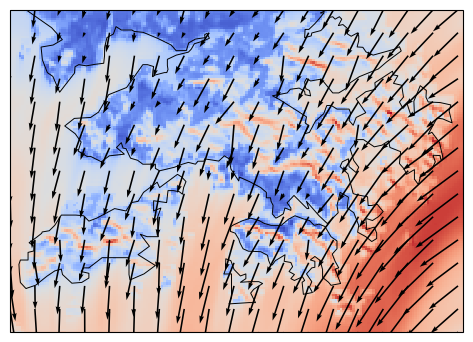

In [3]:
# get wind data
u10 = wind_field['U10']
v10 = wind_field['V10']
lat = wind_field['LAT']
lon = wind_field['LON']
wind_speed = np.hypot(u10, v10)

# create figure
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
fig = plt.figure(figsize=(6, 6))
fig.subplots_adjust(right=0.88)
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([
    float(lon.min()),
    float(lon.max()),
    float(lat.min()),
    float(lat.max()),
], crs=ccrs.PlateCarree())

magnitude = ax.pcolormesh(
    lon,
    lat,
    wind_speed,
    cmap='coolwarm',
    shading='auto',
    transform=ccrs.PlateCarree(),
)

ax.add_feature(cfeature.COASTLINE.with_scale('10m'), linewidth=0.7)

step = 10
vectors = ax.quiver(
    lon[::step, ::step],
    lat[::step, ::step],
    u10[::step, ::step],
    v10[::step, ::step],
    color='black',
    scale=500,
    width=0.0035,
    headwidth=3.0,
    transform=ccrs.PlateCarree(),
)
# ax.quiverkey(vectors, 0.85, 1.05, 20, '20 m/s', labelpos='E', coordinates='axes')

# gridlines = ax.gridlines(draw_labels=True, linewidth=0, color='gray', alpha=0.6, linestyle='--')
# gridlines.top_labels = False
# gridlines.right_labels = False

# ax_pos = ax.get_position()
# cax = fig.add_axes([ax_pos.x1 + 0.02, ax_pos.y0, 0.03, ax_pos.height])
# colorbar = fig.colorbar(magnitude, cax=cax)
# colorbar.set_label('10 m wind speed (m/s)')

# valid_time = wind_field.attrs.get('valid_time', 'Unknown time').replace('_', ' ')
# ax.set_title(f'{valid_time}'+' UTC')

plt.savefig("wind_field_202509232200.tif", dpi=600, bbox_inches='tight')
plt.show()